In [1]:
from fastscape.models import basic_model
import numpy as np
import matplotlib.pyplot as plt
%load_ext xsimlab.ipython

# Notebook 1
Simple example on how to export output from FastScape for display in Paraview

In [2]:
# %create_setup basic_model -v -d
import xsimlab as xs

tf = 5e6
nstep = 101
ds_in = xs.create_setup(
    model=basic_model,
    clocks={'time':np.linspace(0,tf,nstep)},
    input_vars={
        # nb. of grid nodes in (y, x)
        'grid__shape':[101,201],
        # total grid length in (y, x)
        'grid__length':[10e3,20e3],
        # node status at borders
        'boundary__status': 'fixed_value',
        # uplift rate
        'uplift__rate': 1e-3, 
        # bedrock channel incision coefficient
        'spl__k_coef': 1e-5,
        # drainage area exponent
        'spl__area_exp': 0.45,
        # slope exponent
        'spl__slope_exp': 1,
        # diffusivity (transport coefficient)
        'diffusion__diffusivity':0.1 ,
        # random seed
        'init_topography__seed': None,
    },
    output_vars={'topography__elevation':'time',
                 'drainage__area':'time'}
)


In [3]:
with basic_model, xs.monitoring.ProgressBar():
    ds_out = ds_in.xsimlab.run()

             0% | initialize 

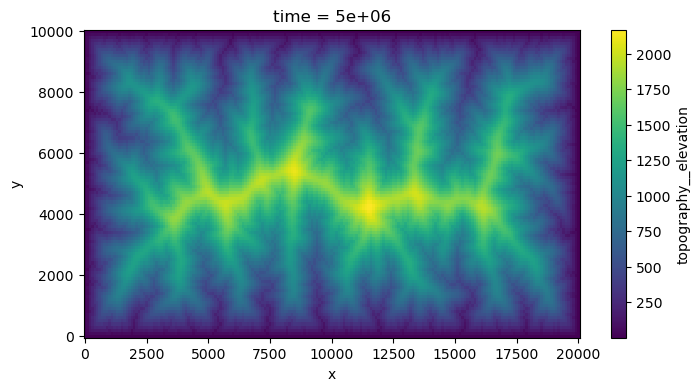

In [4]:
ds_out.topography__elevation.isel(time=-1).plot(size=4, aspect=2);

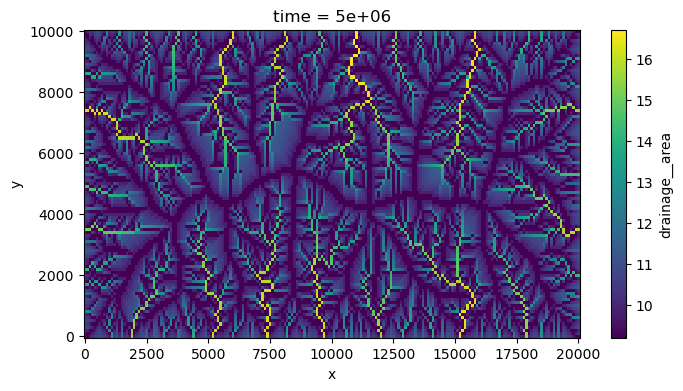

In [5]:
np.log(ds_out.drainage__area).isel(time=-1).plot(size=4, aspect=2);

In [6]:
ds_out.x.attrs["units"]= "m"
ds_out.y.attrs["units"]= "m"
ds_out.time.attrs["units"]= "years"

ds_out.topography__elevation.to_netcdf('Topo.nc')
ds_out.drainage__area.to_netcdf('Area.nc')